**Mounting drive to colab notebook to avoid volatality of Colab's Runtime**

- saving zip file to drive to use in the agent building



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Unzipping the zip file and saving it to the drive**

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/Project/emails.csv.zip"   # path to uploaded zip
extract_path = "/content/drive/MyDrive/Colab Notebooks/Project"  # folder in Drive

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/drive/MyDrive/Colab Notebooks/Project


**Loading csv file to pandas dataframe for classification**

In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Colab Notebooks/Project/emails.csv"
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
                       file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <24216240.1075855687451.JavaMail.e...
3  allen-p/_sent_mail/1000.  Message-ID: <13505866.1075863688222.JavaMail.e...
4  allen-p/_sent_mail/1001.  Message-ID: <30922949.1075863688243.JavaMail.e...


In [ ]:
import re

def parse_email(raw_text):
    headers = {}
    for line in raw_text.split("\n"):
        if line.startswith("Message-ID:"):
            headers["Message-ID"] = line.replace("Message-ID:", "").strip()
        elif line.startswith("From:"):
            headers["From"] = line.replace("From:", "").strip()
        elif line.startswith("Subject:"):
            headers["Subject"] = line.replace("Subject:", "").strip()
    return headers

parsed = df["message"].apply(parse_email)
parsed_df = pd.DataFrame(parsed.tolist())
print(parsed_df.head())

                                      Message-ID                     From  \
0  <18782981.1075855378110.JavaMail.evans@thyme>  phillip.allen@enron.com   
1  <15464986.1075855378456.JavaMail.evans@thyme>  phillip.allen@enron.com   
2  <24216240.1075855687451.JavaMail.evans@thyme>  phillip.allen@enron.com   
3  <13505866.1075863688222.JavaMail.evans@thyme>  phillip.allen@enron.com   
4  <30922949.1075863688243.JavaMail.evans@thyme>  phillip.allen@enron.com   

     Subject  
0             
1        Re:  
2   Re: test  
3             
4  Re: Hello  


**Categorizing emails based on subject**

In [ ]:
def categorize(subject):
    if subject is None:
        return "Unknown"
    subject = subject.lower()
    if "meeting" in subject or "schedule" in subject:
        return "Work"
    elif "invoice" in subject or "payment" in subject:
        return "Finance"
    elif "party" in subject or "invitation" in subject:
        return "Personal"
    else:
        return "Other"

parsed_df["Category"] = parsed_df["Subject"].apply(categorize)
print(parsed_df[["From","Subject","Category"]].head())

                      From    Subject Category
0  phillip.allen@enron.com               Other
1  phillip.allen@enron.com        Re:    Other
2  phillip.allen@enron.com   Re: test    Other
3  phillip.allen@enron.com               Other
4  phillip.allen@enron.com  Re: Hello    Other


In [ ]:
parsed_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Project/categorized_emails.csv", index=False)
print("Categorized dataset saved to Drive!")

Categorized dataset saved to Drive!


In [ ]:
def agent_action(row):
    if row["Category"] == "Work":
        return "Add to calendar / notify team"
    elif row["Category"] == "Finance":
        return "Forward to accounts department"
    elif row["Category"] == "Personal":
        return "Mark as personal / no action"
    else:
        return "Archive"

parsed_df["Agent_Action"] = parsed_df.apply(agent_action, axis=1)
print(parsed_df[["From","Subject","Category","Agent_Action"]].head())

                      From    Subject Category Agent_Action
0  phillip.allen@enron.com               Other      Archive
1  phillip.allen@enron.com        Re:    Other      Archive
2  phillip.allen@enron.com   Re: test    Other      Archive
3  phillip.allen@enron.com               Other      Archive
4  phillip.allen@enron.com  Re: Hello    Other      Archive


In [ ]:
parsed_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Project/final_email_assistant.csv", index=False)
print("Final assistant dataset saved to Drive!")

Final assistant dataset saved to Drive!


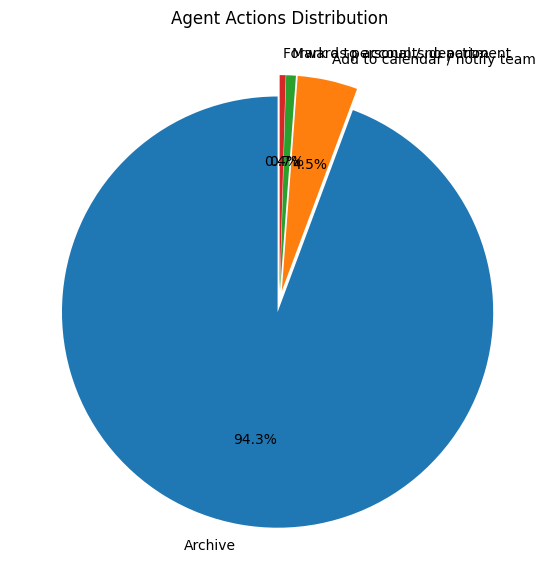

In [ ]:
import matplotlib.pyplot as plt

action_counts = parsed_df['Agent_Action'].value_counts()

explode = [0.05]*len(action_counts)  # separate all slices slightly

action_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7),
    startangle=90,
    explode=explode
)

plt.title("Agent Actions Distribution")
plt.ylabel("")
plt.show()